당신은 온라인 게임을 운영하고 있습니다.

같은 시간대에 게임을 이용하는 사람이 m명 늘어날 때마다 서버 1대가 추가로 필요합니다.

어느 시간대의 이용자가 m명 미만이라면, 서버 증설이 필요하지 않습니다.

어느 시간대의 이용자가 n x m명 이상 (n + 1) x m명 미만이라면 최소 n대의 증설된 서버가 운영 중이어야 합니다.

한 번 증설한 서버는 k시간 동안 운영하고 그 이후에는 반납합니다. 예를 들어, k = 5 일 때 10시에 증설한 서버는 10 ~ 15시에만 운영됩니다.

하루 동안 모든 게임 이용자가 게임을 하기 위해 서버를 최소 몇 번 증설해야 하는지 알고 싶습니다. 같은 시간대에 서버를 x대 증설했다면 해당 시간대의 증설 횟수는 x회입니다.


1. m 명 이상 늘어날 때마다 1대(n대) 추가
2. 시간대의 이용자 n*m이상 (n+1)*m 미만이면 최소 n대 증설
3. 한번 증설한 서버는 k 시간 동안 이용후 반납
4. x대 증설하면 해당시간대 x 회 증설함 -> 증가하면 횟수 늘리기(reslut)


EX

m = 3, k = 5 로 시작 시

n=0 으로 1*3명 미만이니 0대 증설

5시간이 지나면 초기화

In [ ]:
# 풀이
players = [0, 2, 3, 3, 1,    # 시간대별 이용자 수
           2, 0, 0, 0, 0,
           4, 2, 0, 6, 0,
           4, 2, 13, 3, 5,
           10, 0, 1, 5]
m = 3                        # m명이상 늘어날 때
k = 5                        # k 시간 동안 이용

def solution1(players, m, k):
  time_servers = [0] * 24      # 시간별 작동중인 리스트
  add_servers = 0              # 서버 증설횟수
  for idx, people in enumerate(players):                       # enumerate로 시간(idx)과 인원(peo)을 꺼냅니다.
        current_server_count = time_servers[idx]              # 현재 시간에 이미 작동 중인 서버 대수                            # 초기는 현재는 전부 0값
        n = current_server_count                              # n 구간에 있으면 필요한 증설서버는 n대                           # 초기는 0값
        if n * m <= people < (n + 1) * m:                      # 만약 이미 가동 중인 서버(n대)로 커버가 가능한 인원수 범위?       # 초기는 0<= people <3
            pass                                                 # pass
        elif people >= (n + 1) * m:                            # 만약 인원이 (n + 1) * m 명을 넘어가서 서버가 부족하다면?        # 3이 될 경우
            real_need = people // m                              # 이 인원에 필요한 증설 서버 총대수                            # 3//3으로 1대 필요
            add_count = real_need - current_server_count         # 부족한 증설서버 대수                                        # 1-0 = 1 로 1대 부족한 상태
            add_servers += add_count                             # 부족한 만큼 증설 횟수 추가                                   # add_servers에 부족한 만큼 증설
            end_time = min(idx + k, len(players))                  # 시간대(K)별로 유지해야하는 서버 #idx(시간대)+K(주어진 값)   # 최대시간은 24시간  # 최초 3인 경우 2+5로 7시간(end_time) 유지
            for future_time in range(idx, end_time):                 # 앞으로 2부터 7까지 활용                         # 이미 늘어난 경우에는 if 문으로 들어가서 적용 안함
                time_servers[future_time] += add_count               # time_servers에 해당 위치의 값에 add_count을 더함

  return add_servers

print(solution1(players, m, k))


7


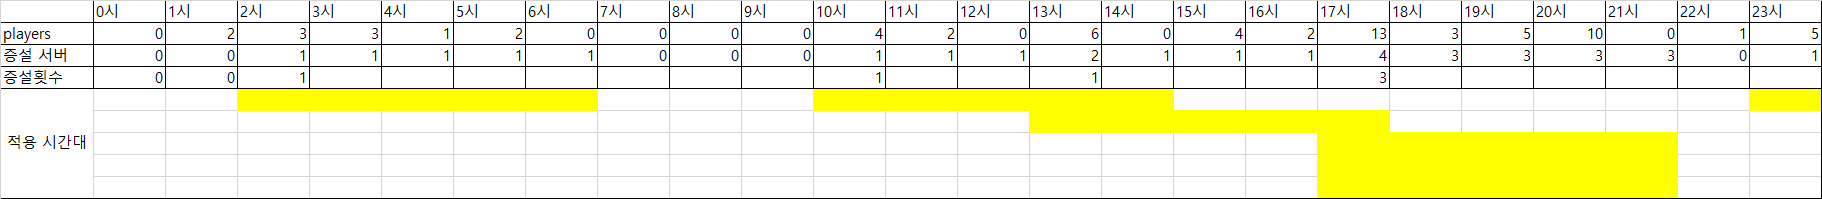

In [ ]:
# ai 돌린 풀이
def solution(players, m, k):
  answer = 0                                         # 최종 서버 총 증설 횟수 주머니
  active_servers = [0] * len(players)                # 시간대별 현재 가동 중인 서버 수
  for idx, peo in enumerate(players):                # 시간(idx)과  해당시간 인원수(peo)
    need_servers = peo // m                            # 현재 시간(idx)에 필요한 총 서버 대수 계산 (몫 연산자 // 활용)
    now_servers = active_servers[idx]                  # 현재 시간(idx)에 이미 가동 중인 서버 대수

    if now_servers < need_servers:                   # 만약 이미 켜진 서버가 필요한 대수보다 부족하다면?
      add_servers = need_servers - now_servers         # 부족한 만큼 추가로 증설해야 할 대수 계산
      answer += add_servers                            # 총 증설 횟수에 누적 더하기

      end_time = min(idx + k, len(players))          # 증설한 서버 대수를 현재부터 미래의 만료 시간 전까지 기록해 줍니다.
                                                     # 현재 시간(idx)부터 k시간 동안만 유지되도록 범위를 잡습니다.
                                                     # 단, 하루(24시)를 넘어가는 범위는 에러가 날 수 있으므로 len(players)까지만 제한합니다.
      for fut_time in range(idx, end_time):
        active_servers[fut_time] += add_servers
  return answer

1. 거리계산 Numpy 활용

In [ ]:
# 실습 1

import numpy as np

pt = np.array([2,3])
ps = np.array([[2,5],[5,6],[6,7]])

print(pt)
print(ps)
print(ps.shape)

[2 3]
[[2 5]
 [5 6]
 [6 7]]
(3, 2)


In [ ]:
# 실습 1 거리계산의 한줄화

#def udistance(pt,ps):
#  dst = []
#  sp = []
#  for p in ps :
#    dst.append(((p[0]-pt[0])**2 + (p[1]-pt[1])**2)**0.5)
#  sp = ps[dst.index(sorted(dst)[0])]
#  dst = sorted(dst)[0]
#  return sp, dst
#print(udistance(pt,ps))


print((((ps-pt)**2).sum(1))**0.5)

[2.         4.24264069 5.65685425]


In [ ]:
# 실습 2

nd1 = np.array([5,6,1,4,2,3])
print(np.argmin(nd1))              # argmin : nd1 의 가장 작은 것의 위치값
print(np.argmax(nd1))              # argmax : nd1 의 가장 큰 것의 위치값
print(np.argsort(nd1))             # argsort : 오름차순으로 정렬했을 때의 가장 작은 것부터의 현재 위치 값

2
1
[2 4 5 3 0 1]


In [ ]:
# 실습 2 함수 적용
def udistance(pt,ps):
  dst = (((ps-pt)**2).sum(1))**0.5    # 거리계산 적용
  sp = np.argmin(dst)                 # 그 중 가장 작은 값의 위치 확인
  return ps[sp], dst[sp]              # 그 위치의 값 출력, 기준점과의 거리 출력

udistance(pt,ps)

(array([2, 5]), np.float64(2.0))

In [260]:
# 실습 3 비율 별 총점

nd1 = np.array([[90,80,70],
               [70,80,80],
               [100,70,70]])
a_score = np.array([[0.5,0.3,0.2]])
print(nd1.shape)
print(a_score.shape)
def scores(nd1, a_score):
  asc = (nd1*a_score).sum(1)                               # 2차원일 때 1이면 열이 아닌 행을 계산
  return asc

scores(nd1, a_score)

(3, 3)
(1, 3)


array([83., 75., 85.])

In [ ]:
# 실습 3 비율 별 총점_심화

names = np.array(["김","이",'정'])
nd1 = np.array([[90,80,70],[70,80,80],[100,70,70]])
ratio = np.array([0.5,0.3,0.2])

rank = np.argsort((nd1*ratio).sum(1))[::-1]

print((nd1*ratio).sum(1))                                     # 개인의 점수
print(np.argsort((nd1*ratio).sum(1)))                         # 정렬(기본 오름차순)
print(names[np.argsort((nd1*ratio).sum(1))])
print(np.argsort((nd1*ratio).sum(1))[::-1])                   # 역순
print(names[np.argsort((nd1*ratio).sum(1))[::-1]])
#print(rank)

[83. 75. 85.]
[1 0 2]
['이' '김' '정']
[2 0 1]
['정' '김' '이']


In [ ]:
# 실습 4 합격인원

def WhoisPassed(names, nd1, ratio, num=1):
  rank = np.argsort((nd1*ratio).sum(1))[::-1][:num]    # nd1*ratio : 선형회귀식
  return names[rank]

WhoisPassed(names, nd1, ratio, 2)

array(['정', '김'], dtype='<U1')

In [ ]:
# 실습 5 타입

nd1 = np.array([[1.,2,3]])    # 실수 타입일 때
nd2 = np.array([[1,2,3]])     # 정수 타입일 때

print(nd1)
print(nd1.shape)
nd1.dtype

[[1. 2. 3.]]
(1, 3)


dtype('float64')

In [ ]:
# 실습 5-1               # 위치정보로 값 불러오기 실행
nd3 = np.array([5,6,7])
print(nd3[nd2[0][1]])    # 정수타입은 가능
#print(nd3[nd1[0][1]])    # 실수타입은 오류


7


In [ ]:
#실습 5-2

import sys
print(sys.version)

a = 6/4             # 과거 버전에선 정수/정수는 정수로만 나왔음
print(a)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
1.5


In [ ]:
# 실습 6

nd1 = np.arange(0,1.2,0.1).reshape(3,4)  # 0~1.2까지 0.1씩 (3,4) 모양으로
print(nd1)

lst1 = ([[1,2,3],[4,5,6]])    # 리스트를 array로 변경하는 방법 // 차이점
nd2 = np.array(lst1)                                           # 내부 데이터로만 가져감
nd3 = np.asarray(lst1)                                         # 새로운 array로 변경
print(nd2)
print(nd3)

[[0.  0.1 0.2 0.3]
 [0.4 0.5 0.6 0.7]
 [0.8 0.9 1.  1.1]]
[[1 2 3]
 [4 5 6]]
[[1 2 3]
 [4 5 6]]


In [ ]:
#실습 6-1
nd1 = np.ones((2,3))        # 1만 들어가있는 (2,3) 모양의 데이터
nd2 = np.zeros((2,3))       # 0만 들어가있는 (2,3) 모양의 데이터  # 데이터 모양 설정
nd3 = np.zeros_like((nd2))  # 0만 들어가있는 nd2 모양의 데이터    # 모방할 모양 설정
print(nd1)
print(nd2)
print(nd3)

[[1. 1. 1.]
 [1. 1. 1.]]
[[0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]]


In [ ]:
# 실습 6-2
nd1=np.array([1,2,3], dtype=np.float32)
print(nd1)

nd2=nd1.astype(np.int32)
print(nd2)

lst2 = nd2.tolist()                    # 행추가 할 때 유익하게 응용가능(리스트로 변경하여 사용 후 다시 array 로 변경)
print(lst2)

[1. 2. 3.]
[1 2 3]
[1, 2, 3]


In [ ]:
# 실습 7

nd1 = np.arange(24).reshape(2,3,4)
print(nd1)
print(nd1.flatten())                # 차원을 1차원으로 조정해줌

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [ ]:
# 실습 7-1 축 생성
nd1 = np.array([1,2,3])               # (3,) shape
print(nd1, nd1.shape)
nd2=nd1[:,np.newaxis]                 # (3,) shape 에 오른쪽에 asxis 추가됨
print(nd2, nd2.shape)
nd3 = nd1[np.newaxis,:]               # (3,) shape 에 왼쪽에 asxis 추가됨
print(nd3, nd3.shape)
nd4 = nd1[np.newaxis,:,np.newaxis]    # (3,) shape 에 양쪽에 asxis 추가됨
print(nd4, nd4.shape)

[1 2 3] (3,)
[[1]
 [2]
 [3]] (3, 1)
[[1 2 3]] (1, 3)
[[[1]
  [2]
  [3]]] (1, 3, 1)


# 불리언 색인

In [268]:
# 실습 8   특정 데이터 도출

names = np.array(['김','조', '최', '정','김', '조', '박'])
np.random.seed(85588)
data = np.random.randn(7,4)
print(data)

[[-0.38527641 -0.79723381 -1.48366131  0.39082666]
 [ 1.42299621 -0.06808593  0.66308049 -1.37771319]
 [-1.31901408 -0.19626974  0.60491672  0.74832396]
 [-0.36541217  0.64027794  1.08924257 -1.25029531]
 [-0.28991074  0.45570544  0.84237912 -0.74902555]
 [-0.50860683 -0.22267959 -0.37742855  1.56294182]
 [ 1.52949516 -1.26550079  0.30091294  0.4022667 ]]


In [ ]:
# 실습 8-1

print(names=='김')
print(data[names=='김'])
print(data[names=='김', 2:])
print(data[(names=='김') | (names=='정')])       # () 없으면 에러

[ True False False False  True False False]
[[-0.46820879 -0.82282485 -0.0653801  -0.71336192]
 [-1.23323138 -0.43950352  0.91478726  0.26504093]]
[[-0.0653801  -0.71336192]
 [ 0.91478726  0.26504093]]
[[-0.46820879 -0.82282485 -0.0653801  -0.71336192]
 [-0.76935745 -1.40309592 -0.63246751 -0.55887367]
 [-1.23323138 -0.43950352  0.91478726  0.26504093]]


In [ ]:
# 실습 8-2

data[data<-1] = -1
data[data>1] = 1

print(data)

[[-0.46820879 -0.82282485 -0.0653801  -0.71336192]
 [ 0.90635089  0.76623673  0.82605407 -1.        ]
 [-1.          1.          0.54480945  1.        ]
 [-0.76935745 -1.         -0.63246751 -0.55887367]
 [-1.         -0.43950352  0.91478726  0.26504093]
 [-1.          0.6855118   0.45609091 -0.46137426]
 [ 0.0947003  -1.          1.          0.45686676]]


In [ ]:
# 실습 9

np.random.seed(777)
data = np.random.randn(7,4)
                 # if         # esif             # else
data1 = np.where(data<-1, -1, np.where(data>1, 1, data))
print(data1)

data1.transpose()                                           # 행열을 서로 바꿈

[[-0.46820879 -0.82282485 -0.0653801  -0.71336192]
 [ 0.90635089  0.76623673  0.82605407 -1.        ]
 [-1.          1.          0.54480945  1.        ]
 [-0.76935745 -1.         -0.63246751 -0.55887367]
 [-1.         -0.43950352  0.91478726  0.26504093]
 [-1.          0.6855118   0.45609091 -0.46137426]
 [ 0.0947003  -1.          1.          0.45686676]]


In [ ]:
# 실습 9-1

nd1 = np.arange(24).reshape(2,3,4)
print(nd1, nd1.shape)
nd1.transpose(0,2,1)                                       # 0번 축을 0으로 / 1번축을 2로 / 2번축을 1로 바꿔라 (주로 볼 것이 속성이라고 생각하면 됨)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]] (2, 3, 4)


In [ ]:
# 실습 10
np.save("nd1.npy",nd1)     # 생성된 거 저장

In [ ]:
nd10 = np.load("nd1.npy")  # 불러오기(단, 임시라서 별도로 저장해야함)
print(nd10)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]


In [ ]:
from google.colab import drive
# drive.mount('/content/gdrive')
# /content/gdrive/MyDrive/Colab Notebooks/파이썬 실습/nd1.npy
nd11 = np.load("/content/gdrive/MyDrive/Colab Notebooks/파이썬 실습/nd1.npy")
print(f"npy 파일 \n {nd11}")

nd1 = np.loadtxt("/content/gdrive/MyDrive/Colab Notebooks/파이썬 실습/numpy_ex.txt", delimiter=',')  # ,의 구분자는 , 임을 알려주는것 # 기본값은 실수형임
print(f"텍스트 파일 \n {nd1}")

npy 파일 
 [[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
텍스트 파일 
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]


In [ ]:
# 번외   # 랜덤 뽑기1
members = ['김찬은', '송문택', '윤창기', '최진주', '류경혜',
           '김진경', '최호연', '노현동', '배원준', '정선영',
           '민승희', '임지수', '안지예', '김민주', '한예진',
           '유은영', '김인석', '이수인', '정종현', '허찬빈',
           '진혜원', '남궁세정']
print(f"당첨!! {members[np.random.randint(len(members))]}")

당첨!! 정선영


In [ ]:
# 번외   # 랜덤 뽑기2

counter = np.zeros_like(members, dtype=np.int32)
for _ in range(100000):
  counter[np.random.randint(len(members))] += 1
print(f"당첨!! {members[np.argmax(counter)]}")

당첨!! 허찬빈


(188, 268, 3)


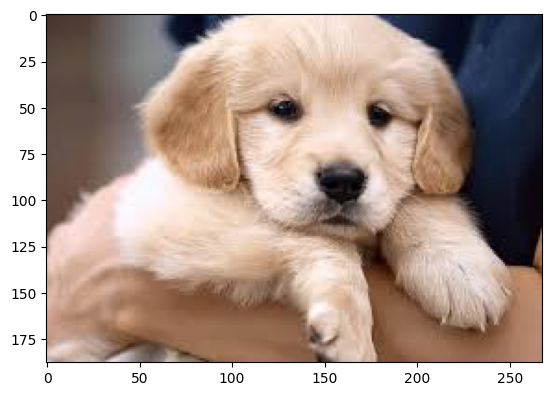

(225, 225, 3)


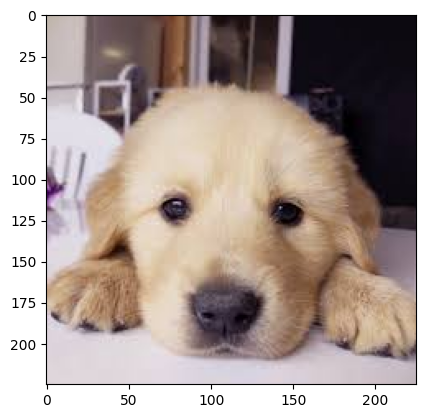

In [ ]:
# 실습 11 사진으로 놀기 2 : 사진 겹치기

from PIL import Image
import matplotlib.pyplot as plt

ndd = Image.open("/content/gdrive/MyDrive/Colab Notebooks/파이썬 실습/Test.jpg")
ndd1 = np.array(ndd)
print(ndd1.shape)
plt.imshow(ndd1)
plt.show()
ndd2 = Image.open("/content/gdrive/MyDrive/Colab Notebooks/파이썬 실습/test2.jpg")
ndd22 = np.array(ndd2)
print(ndd22.shape)
plt.imshow(ndd22)
plt.show()

array([[[163, 160, 179],
        [201, 198, 209],
        [218, 213, 217],
        ...,
        [245, 219, 206],
        [247, 221, 208],
        [242, 216, 203]],

       [[176, 172, 187],
        [228, 222, 232],
        [235, 229, 231],
        ...,
        [244, 218, 205],
        [244, 218, 205],
        [243, 217, 202]],

       [[172, 166, 178],
        [234, 227, 234],
        [244, 236, 234],
        ...,
        [242, 216, 203],
        [241, 215, 202],
        [244, 218, 203]],

       ...,

       [[ 10,  12,  33],
        [ 10,  12,  33],
        [ 10,  12,  33],
        ...,
        [241, 219, 208],
        [241, 219, 208],
        [240, 220, 211]],

       [[  9,  11,  32],
        [  9,  11,  32],
        [  9,  11,  32],
        ...,
        [240, 218, 207],
        [239, 217, 206],
        [242, 222, 213]],

       [[ 10,  11,  32],
        [ 10,  11,  32],
        [ 10,  11,  32],
        ...,
        [239, 217, 206],
        [238, 216, 205],
        [243, 223, 214]]], dtype=uint8)
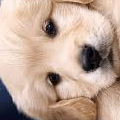

In [263]:
ndd111 = ndd1[:,:,:][1:121,101:221] # 사진 자르기
ndd111.transpose(1,0,2)             # 돌리기

array([[[201, 177, 153],
        [202, 178, 154],
        [203, 179, 155],
        ...,
        [220, 211, 214],
        [225, 216, 219],
        [224, 218, 220]],

       [[201, 179, 155],
        [203, 181, 157],
        [204, 182, 158],
        ...,
        [219, 210, 213],
        [228, 219, 222],
        [224, 218, 220]],

       [[203, 181, 157],
        [205, 183, 159],
        [207, 185, 161],
        ...,
        [218, 209, 212],
        [230, 221, 224],
        [225, 219, 221]],

       ...,

       [[182, 152, 124],
        [174, 145, 115],
        [173, 144, 114],
        ...,
        [158, 136, 148],
        [157, 137, 149],
        [185, 164, 179]],

       [[179, 149, 121],
        [172, 142, 114],
        [171, 142, 112],
        ...,
        [159, 137, 149],
        [155, 135, 147],
        [180, 162, 174]],

       [[174, 144, 118],
        [168, 138, 112],
        [168, 138, 110],
        ...,
        [152, 131, 138],
        [145, 125, 136],
        [176, 158, 170]]], dtype=uint8)
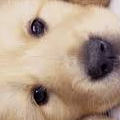

In [262]:
ndd222 = ndd22[:,:,:][81:201,51:171]
ndd222.transpose(1,0,2)             # 돌리기

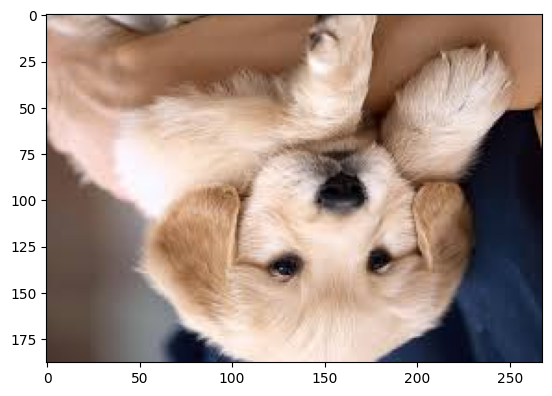

In [ ]:
plt.imshow(ndd1[::-1]) # 상하반전
plt.show()

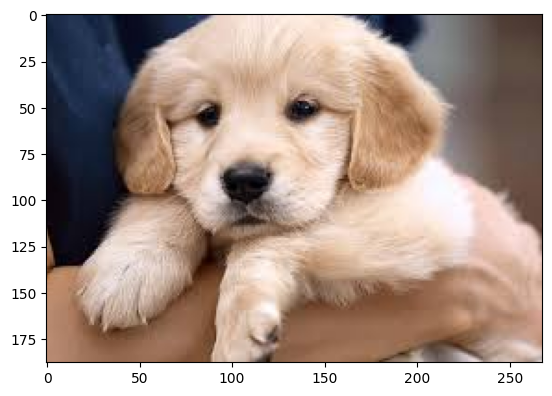

In [ ]:
plt.imshow(ndd1[:,::-1]) # 좌우반전
plt.show()

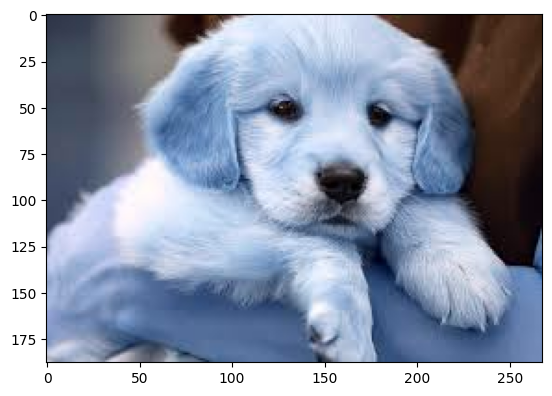

In [ ]:
plt.imshow(ndd1[:,:,::-1]) # 색반전
plt.show()

(120, 120, 3)
(120, 120, 3)


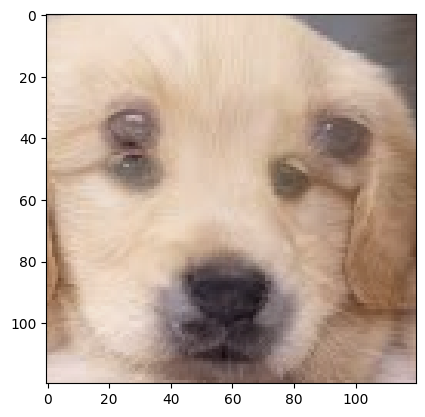

In [ ]:
# 실습 과제
# 사진을 각각 50%씩 섞어서 출력 # ndd111 과 ndd222
ratio = np.array([0.5,0.5])
print(ndd111.shape)
print(ndd222.shape)
plt.imshow(ndd111//2 + ndd222//2)
plt.show()

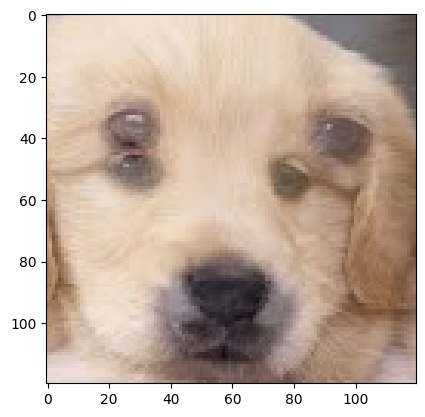

In [ ]:
# 또다른 풀이 방법(AI 활용)

mixed_float = ndd111.astype(np.float32) * 0.5 + ndd222.astype(np.float32) * 0.5
mixed = mixed_float.astype(np.uint8)
plt.imshow(mixed)
plt.show()